In [2]:
from  webdav3.client import Client
import pandas as pd
import os
import numpy as np
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import (precision_score, 
        recall_score, f1_score, roc_auc_score, 
        accuracy_score, classification_report, confusion_matrix
        )
import warnings
from sklearn.metrics import (brier_score_loss, log_loss,
        matthews_corrcoef, accuracy_score)

from hmeasure import h_score
from datetime import datetime
import os
from pathlib import Path
import seaborn as sns

teams = {
    "Baseline": "Baseline",
    "Tim_01": "accelerate healthcare",
    "Tim_02": "Artificial Innovators",
    "Tim_03": "ATMC",
    "Tim_04": "Blizanci",
    "Tim_05": "Care4You",
    "Tim_06": "Foo",
    "Tim_07": "Hessijanci",
    "Tim_08": "IMPERIA",
    "Tim_09": "Kotao",
    "Tim_10": "Kronos",
    "Tim_11": "LIMMB",
    "Tim_12": "LMHS 1",
    "Tim_13": "LMHS 2",
    "Tim_14": "MediBoost",
    "Tim_15": "MedIQ",
    "Tim_16": "Miracool",
    "Tim_17": "Orion",
    "Tim_18": "Panacea",
    "Tim_19": "ReAdmit",
    "Tim_20": "RehopPrevent",
    "Tim_21": "SiraćHC",
    "Tim_22": "tim ReAdmitNet",
    "Tim_23": "Tim Tim",
    "Tim_24": "zesoi",
    "Tim_25": "ZMF",
    "Tim_26": "K-nearest winners",
    "Tim_27": "",
    "Tim_28": "C tim",
}
cmap = {'MediBoost': '#01b4dd',
 'Kronos': '#212529',
 'Baseline': '#bab9bb',
 'SiraćHC': '#f29042',
 'ZMF': '#d83187',
 'ATMC': '#e31a1c',
 'IMPERIA': '#24195c',
 'LMHS 1': '#fffc00',
 'Artificial Innovators': '#228b22',
 'irb-red': '#d92725',
 'irb-blue': '#22458b',
 'irb-gray': '#bab9bb',
 'Challengers': '#988fca',}

bw_teams = {v: k for k, v in teams.items()}     
FONTSIZE = 36
MARKERSCALE = 4
FONTNAME = 'Arial'
mpl.rc('font',family=FONTNAME)
# mpl.rcParams["pdf.fonttype"] = 3
# mpl.rcParams["pdf.fonttype"] = "path"

In [3]:
dirs = os.listdir('task_phase1/EDIH_AI4Health_Challenge')
df = pd.DataFrame([])
cls = ['H_measure','MCC','F1','ROC_AUC','Accuracy',]
top3 = ['MediBoost', 'SiraćHC', 'ZMF', 'Baseline']
#in teams find top 3
top3dirs = []
for k, v in teams.items():
    if v in top3:
        top3dirs.append(k)
hs=[]
mccs=[]
f1s=[]
rocaucs=[]
top3dict = {}
mcc_max = 0
hs_max = 0
f1_max = 0
roc_auc_max = 0
top_metrics_dict = {}
teams_list = []
for d in dirs:
    
    if os.path.isfile(f'task_phase1/EDIH_AI4Health_Challenge/{d}/metrics_private2.csv'):
        mp = pd.read_csv(f'task_phase1/EDIH_AI4Health_Challenge/{d}/metrics_private2.csv')
        hs += list(mp["H_measure"].values)
        mccs += list(mp["MCC"].values)
        f1s += list(mp["F1"].values)
        rocaucs += list(mp["ROC_AUC"].values)
        teams_list += [teams[d] for _ in range(len(mp))]
        if d in top3dirs:
            top3dict[teams[d]] = {'H_measure':mp["H_measure"].values[-1],
                        'mcc':mp["MCC"].values[-1],
                        'f1':mp["F1"].values[-1],
                        'roc_auc':mp["ROC_AUC"].values[-1],}
        for h,m in zip(mp["H_measure"].values, mp["MCC"].values):
            if h > hs_max and m > mcc_max:
                hs_max = h
                mcc_max = m
                top3dict[teams[d]] = {'H_measure':h,
                        'mcc':m,
                        'f1':mp["F1"].values[-1],
                        'roc_auc':mp["ROC_AUC"].values[-1],}
                top_metrics_dict['H_measure'] = {'team': teams[d], 'value': h}
                top_metrics_dict['MCC'] = {'team': teams[d], 'value': m}
        for f1 in mp["F1"].values:
            if f1 > f1_max:
                f1_max = f1
                # top3dict[teams[d]] = {'H_measure':mp["H_measure"].values[-1],
                #         'mcc':mp["MCC"].values[-1],
                #         'f1':f1,
                #         'roc_auc':mp["ROC_AUC"].values[-1],}
                top_metrics_dict['F1'] = {'team': teams[d], 'value': f1}
        for roc_auc in mp["ROC_AUC"].values:
            if roc_auc > roc_auc_max:
                roc_auc_max = roc_auc
                # top3dict[teams[d]] = {'H_measure':mp["H_measure"].values[-1],
                #         'mcc':mp["MCC"].values[-1],
                #         'f1':mp["F1"].values[-1],
                #         'roc_auc':roc_auc,}
                top_metrics_dict['ROC_AUC'] = {'team': teams[d], 'value': roc_auc}

Total number of submissions is 120 valid submissions in the first round

In [4]:
from sklearn.feature_selection import f_regression, mutual_info_regression
#spearmans correlation
from scipy.stats import spearmanr

In [5]:
data = pd.DataFrame({'MCC': mccs, 'H_measure': hs, 'F1': f1s, 'ROC_AUC': rocaucs, 'Team': teams_list})
data_ = data.dropna()
mi = mutual_info_regression( data_[['H_measure', 'F1', 'ROC_AUC']], data_[['MCC']])
mi_norm = mi/  np.max(mi)
print(f"MI MCC-H: {mi[0]:.2f}, MI MCC-F1: {mi[1]:.2f}, MI MCC-ROC_AUC: {mi[2]:.2f}")
spearman, _ = spearmanr(data_[['MCC']], data_['H_measure'])
print(f"Spearman MCC-H: {spearman:.2f}")

MI MCC-H: 1.75, MI MCC-F1: 1.40, MI MCC-ROC_AUC: 0.80
Spearman MCC-H: 0.92


c:\Experiments\chpkg\chpy311\Lib\site-packages\sklearn\utils\validation.py:1111: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


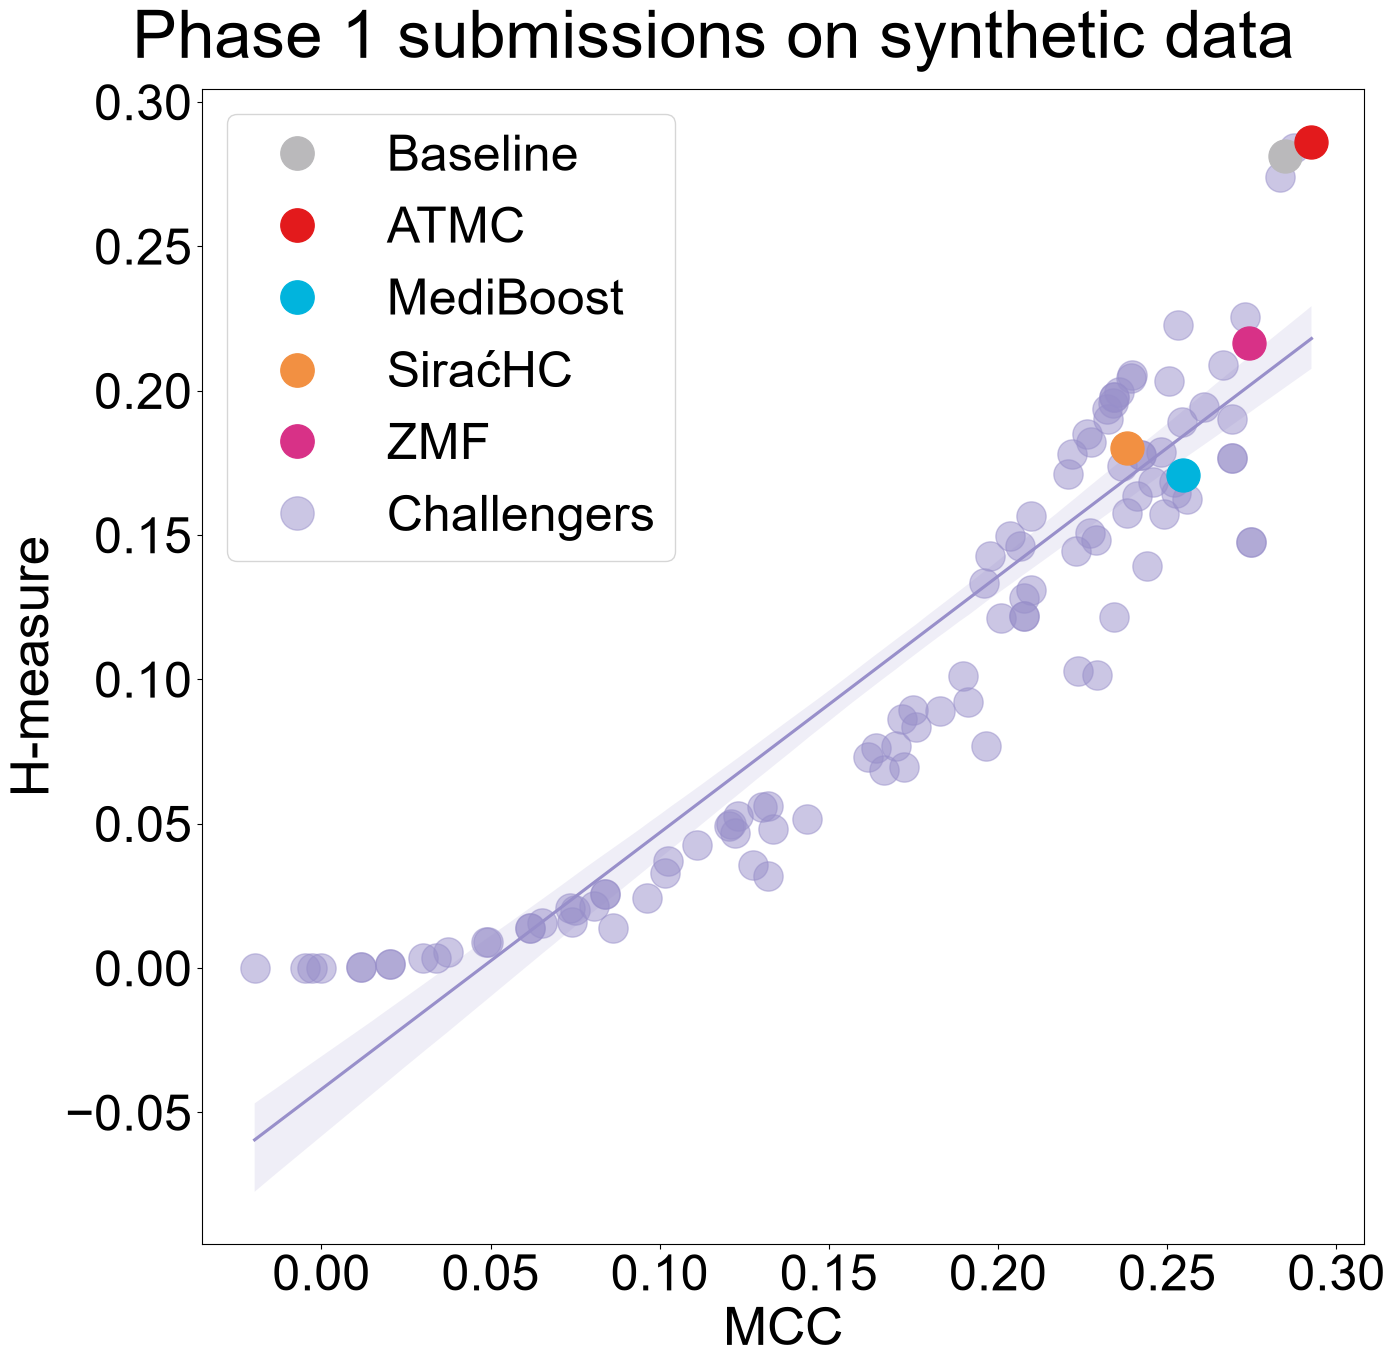

In [6]:
# sns.set_style("white")
data = data.groupby('Team').apply(lambda x: x.iloc[-10:])
data.reset_index(drop=True, inplace=True)
for ky in top3dict.keys():
    data = pd.concat([data, pd.DataFrame({'MCC': top3dict[ky]['mcc'], 
        'H_measure': top3dict[ky]['H_measure']}, index=[len(data)])], 
                    ignore_index=True, axis=0)
    
plt.figure(figsize=(15, 15))
plt.title('Phase 1 submissions on synthetic data', 
        fontsize=FONTSIZE+12, fontname=FONTNAME, y=1.02, x=0.44)

# Create the scatter plot with regression line
data.plot.scatter(x='MCC', y='H_measure', alpha=0.5,
                c=cmap['Challengers'], s=444,ax=plt.gca())

colors = []
names = []   
sns.regplot(data=data, x='MCC', y='H_measure', color=cmap['Challengers'], scatter=False)
for ky in top3dict.keys():
    plt.scatter(top3dict[ky]['mcc'], top3dict[ky]['H_measure'], 
                color=cmap[ky], s = 564)
    colors.append(cmap[ky])
    names.append(ky)
names.append('Challengers')
markers = [plt.Line2D([0,0],[0,0],color=c, marker='o', linestyle=''
                    ) for c in colors]
markers.append(plt.Line2D([0,0],[0,0],color=cmap['Challengers'], marker='o', linestyle='', alpha=0.5))
plt.legend(markers, names, numpoints=1, 
        markerscale=MARKERSCALE, fontsize=FONTSIZE)

plt.xlabel('MCC', fontsize=FONTSIZE+2, fontname=FONTNAME)
plt.ylabel('H-measure', fontsize=FONTSIZE+2, fontname=FONTNAME)
plt.xticks(fontsize=FONTSIZE, fontname=FONTNAME)
plt.yticks(fontsize=FONTSIZE, fontname=FONTNAME)
title = 'phase_1_submissions_on_synthetic_data'
os.makedirs('images', exist_ok=True)
plt.savefig(f'images/{title}.pdf', bbox_inches='tight', format="pdf")
# Show the plot
plt.show()

C:\Users\keber\AppData\Local\Temp\ipykernel_39864\1328580039.py:2: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  data = data.groupby('Team').apply(lambda x: x.iloc[-10:])


<Figure size 1500x1500 with 0 Axes>

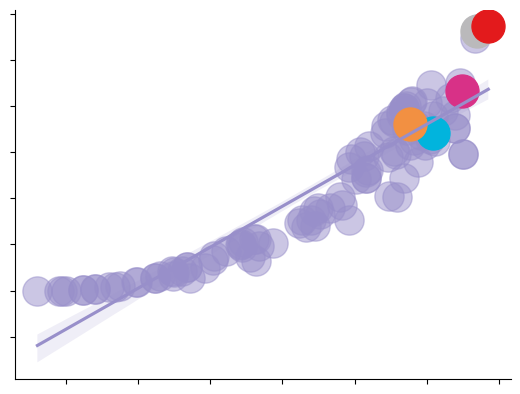

In [7]:
# sns.set_style("white")
data = data.groupby('Team').apply(lambda x: x.iloc[-10:])
data.reset_index(drop=True, inplace=True)
for ky in top3dict.keys():
    data = pd.concat([data, pd.DataFrame({'MCC': top3dict[ky]['mcc'], 
        'H_measure': top3dict[ky]['H_measure']}, index=[len(data)])], 
                    ignore_index=True, axis=0)
plt.figure(figsize=(15, 15))
# plt.title('Phase 1 submissions on synthetic data', fontsize=FONTSIZE+12)

# Create the scatter plot with regression line
data.plot.scatter(x='MCC', y='H_measure', alpha=0.5,
                c=cmap['Challengers'], s=444,)

colors = []
names = []   
sns.regplot(data=data, x='MCC', y='H_measure', color=cmap['Challengers'], scatter=False)
for ky in top3dict.keys():
    plt.scatter(top3dict[ky]['mcc'], top3dict[ky]['H_measure'], 
                color=cmap[ky], s = 564)
    colors.append(cmap[ky])
    names.append(ky)
markers = [plt.Line2D([0,0],[0,0],color=c, marker='o', linestyle=''
                    ) for c in colors]
# plt.legend(markers, names, numpoints=1, 
#            markerscale=MARKERSCALE, fontsize=FONTSIZE)
# hide x and y axes

# hide the spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlabel('', fontsize=FONTSIZE+2)
plt.ylabel('', fontsize=FONTSIZE+2)
plt.xticks(fontsize=FONTSIZE, visible=False)
plt.yticks(fontsize=FONTSIZE, visible=False)
title = 'phase_1_submissions_on_synthetic_data_no_axes'
os.makedirs('images', exist_ok=True)
plt.savefig(f'images/{title}.pdf', bbox_inches='tight', format="pdf")
# Show the plot
plt.show()

In [8]:
baseline_data = pd.read_csv('task_phase1\EDIH_AI4Health_Challenge\Baseline\Baseline_1_27022024.csv', index_col=0)
test_data = pd.read_csv('C:\\Experiments\\chpkg\\Challenge synthetic\\test-synthetic_over_shuffled.csv', index_col=0)
test_data.Label.value_counts(normalize=True)

0    0.94343
1    0.05657
Name: Label, dtype: float64

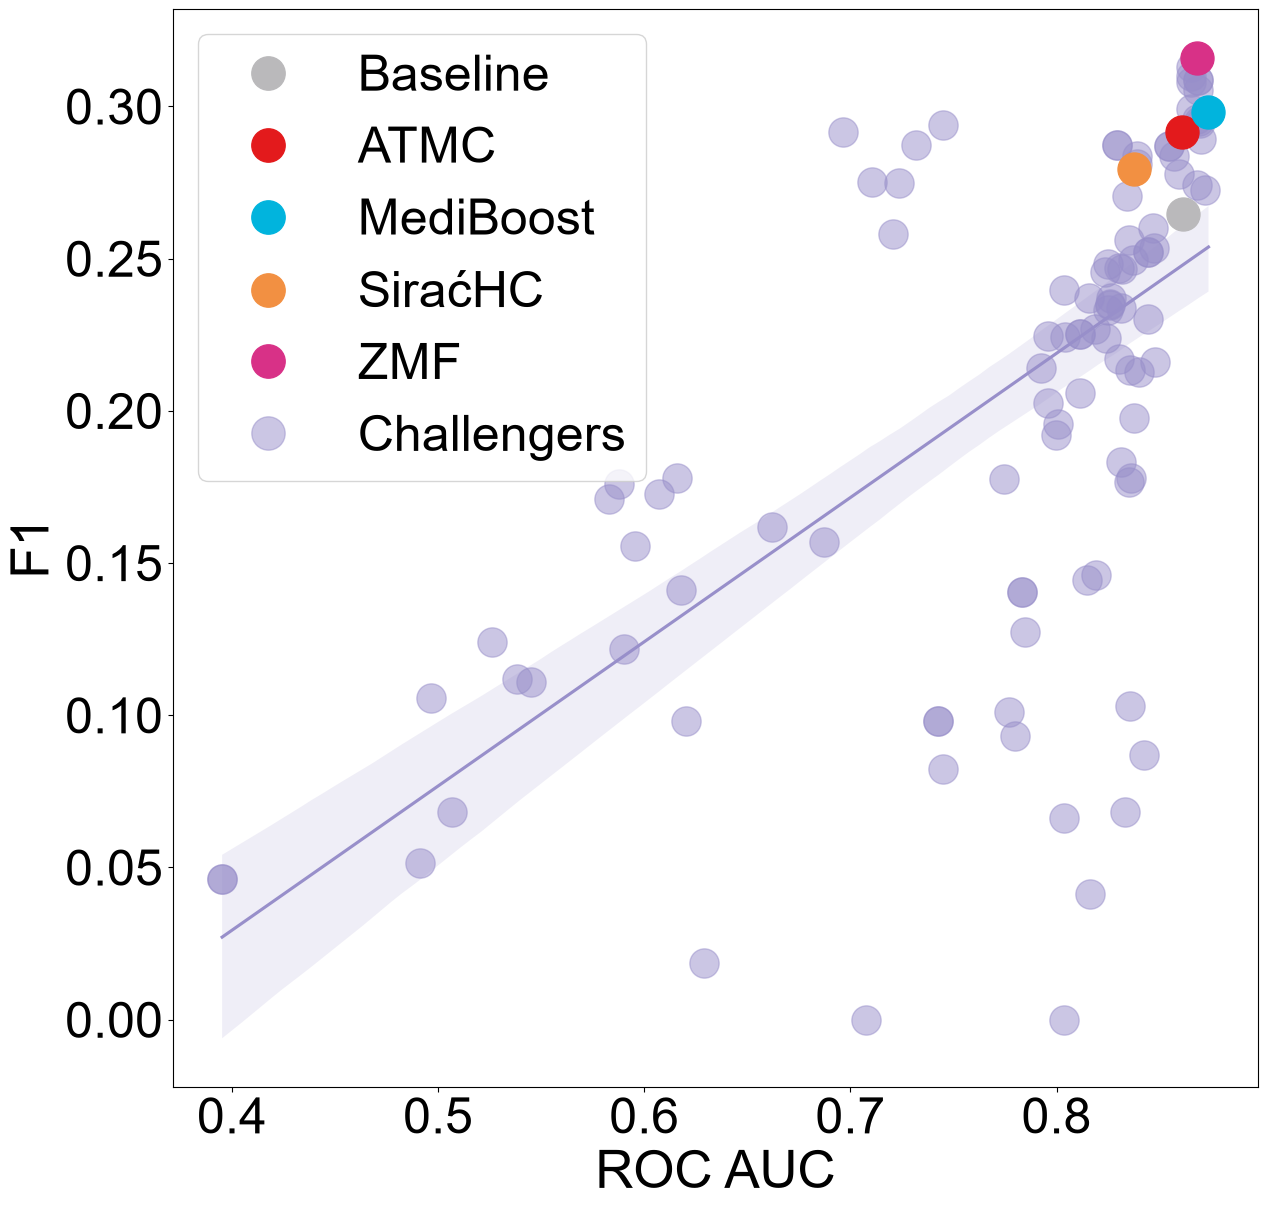

In [9]:
data = pd.DataFrame({'MCC': mccs, 'H_measure': hs, 'F1': f1s, 'ROC AUC': rocaucs, 'Team': teams_list})
# sns.set_style("white")
data = data.groupby('Team').apply(lambda x: x.iloc[-10:])
data.reset_index(drop=True, inplace=True)
for ky in top3dict.keys():
    data = pd.concat([data, pd.DataFrame({'ROC AUC': top3dict[ky]['roc_auc'], 
        'F1': top3dict[ky]['f1']}, index=[len(data)])], ignore_index=True,
                    axis=0)
plt.figure(figsize=(14, 14))
data.plot.scatter(x='ROC AUC', y='F1', alpha=0.5,
                c=cmap['Challengers'], s=444,ax=plt.gca())
    
sns.regplot(data=data, x='ROC AUC', y='F1', color=cmap['Challengers'], 
            scatter=False, ax=plt.gca())	

for ky in top3dict.keys():
    plt.scatter(top3dict[ky]['roc_auc'], top3dict[ky]['f1'], 
                color=cmap[ky], s = 564)
# size of the axis labels
plt.xlabel('ROC AUC', fontsize=FONTSIZE+2, fontname=FONTNAME)
plt.ylabel('F1', fontsize=FONTSIZE+2, fontname=FONTNAME)
plt.xticks(fontsize=FONTSIZE, fontname=FONTNAME)
plt.yticks(fontsize=FONTSIZE, fontname=FONTNAME)
names.append('Challengers')
markers = [plt.Line2D([0,0],[0,0],color=c, marker='o', linestyle=''
                    ) for c in colors]

markers.append(plt.Line2D([0,0],[0,0],color=cmap['Challengers'], marker='o', 
                        linestyle='', alpha=0.5))

plt.legend(markers, names, numpoints=1, 
        markerscale=MARKERSCALE, fontsize=FONTSIZE)
title = 'phase_1_roc_auc_vs_f1'
os.makedirs('images', exist_ok=True)
plt.savefig(f'images/{title}.pdf', bbox_inches='tight', format="pdf")
plt.show()
# Show the plot
plt.show()

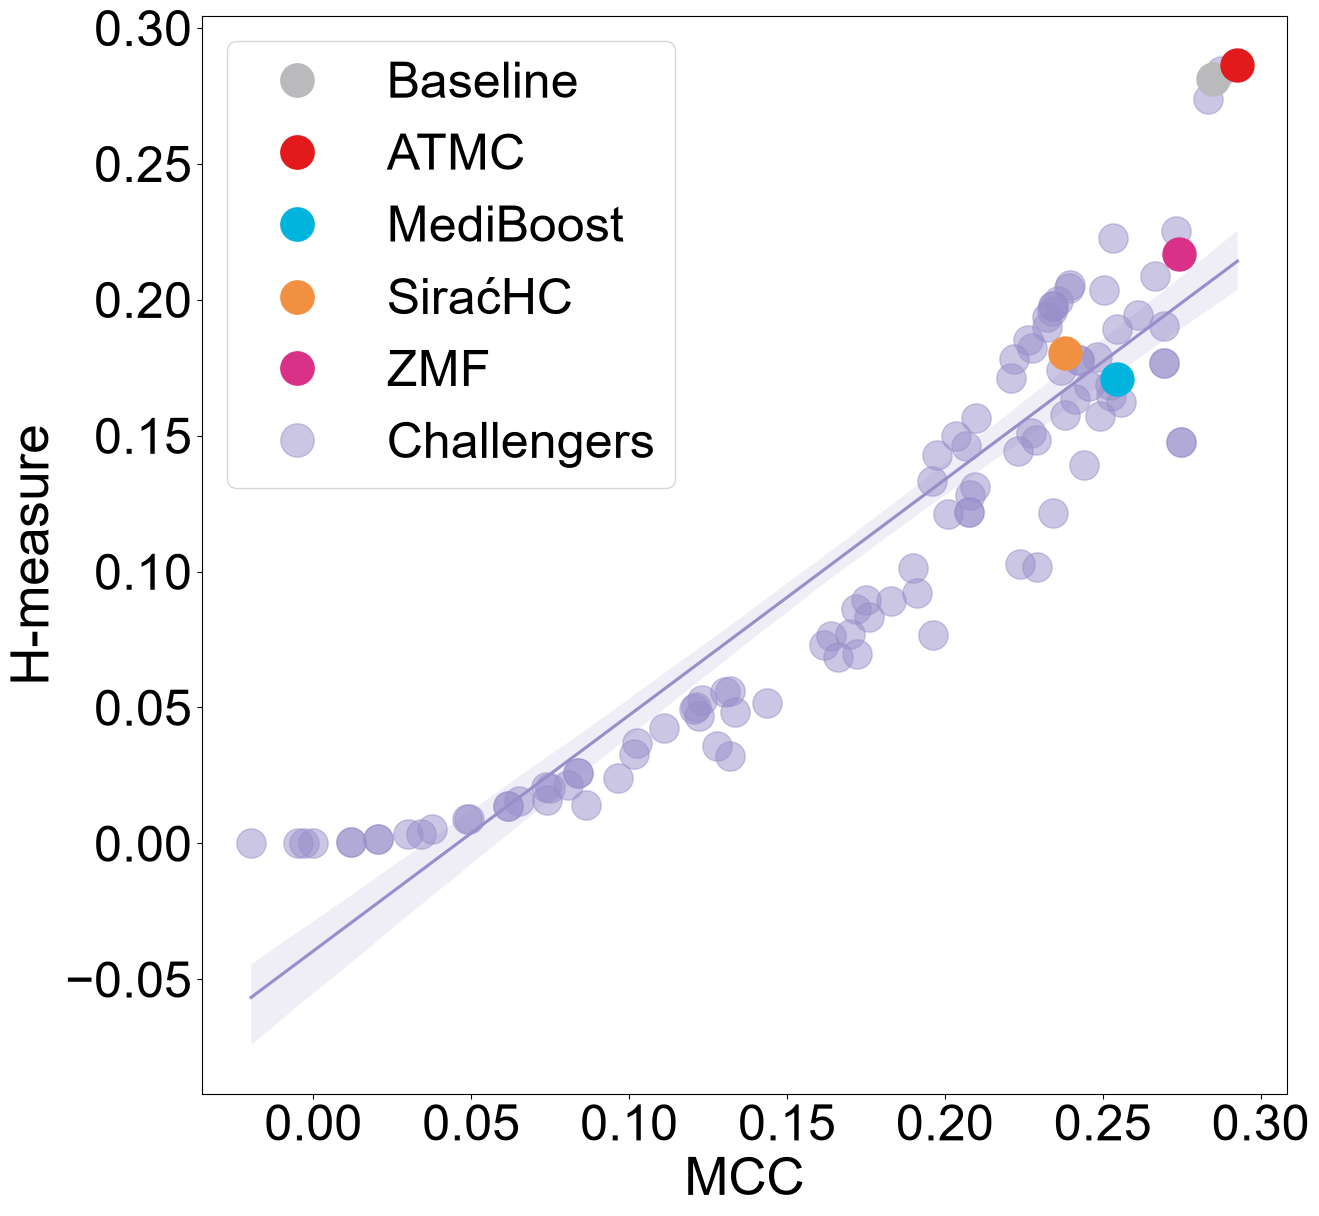

In [10]:
plt.figure(figsize=(14, 14))
# plt.title('Phase 1 submissions on synthetic data', fontsize=FONTSIZE+12)
data.plot.scatter(x='MCC', y='H_measure', alpha=0.5,
                c=cmap['Challengers'], s=444, ax=plt.gca())

sns.regplot(data=data, x='MCC', y='H_measure',
            color=cmap['Challengers'], scatter=False, ax=plt.gca())

for ky in top3dict.keys():
    plt.scatter(top3dict[ky]['mcc'], top3dict[ky]['H_measure'], 
                color=cmap[ky], s = 564)

markers = [plt.Line2D([0,0],[0,0],color=c, marker='o', linestyle=''
                    ) for c in colors]
markers.append(plt.Line2D([0,0],[0,0], color=cmap['Challengers'], 
                          marker='o', linestyle='', alpha=0.5))

plt.legend(markers, names, numpoints=1, 
           markerscale=MARKERSCALE, fontsize=FONTSIZE)

plt.xlabel('MCC', fontsize=FONTSIZE+2, fontname=FONTNAME)
plt.ylabel('H-measure', fontsize=FONTSIZE+2, fontname=FONTNAME)
plt.xticks(fontsize=FONTSIZE, fontname=FONTNAME)
plt.yticks(fontsize=FONTSIZE, fontname=FONTNAME)
title = 'phase_1_mcc_vs_h_measure'
os.makedirs('images', exist_ok=True)
plt.savefig(f'images/{title}.pdf', bbox_inches='tight', format="pdf")
# Show the plot
plt.show()

In [11]:
mccs = np.array(mccs)
hs = np.array(hs)
f1s = np.array(f1s)
rocaucs = np.array(rocaucs)
df_swarmplot = pd.DataFrame({'MCC':mccs, 'H-measure':hs, 'F1':f1s, 'ROC AUC':rocaucs, 'Teams':teams_list})
df_swarmplot = df_swarmplot.groupby('Teams').apply(lambda x: x.iloc[-10:])
df_swarmplot.reset_index(drop=True, inplace=True)
df_m = df_swarmplot.melt(id_vars='Teams', var_name='Metric', value_name='Value')
df_m['Teams'] = df_m['Teams'].apply(lambda x: x if x in cmap.keys() else 'Challengers')
colors = [cmap[key] for key in df_m['Teams'].unique()]
palette = sns.color_palette(colors, len(df_m['Teams'].unique()))
df_m.shape

(572, 3)

C:\Users\keber\AppData\Local\Temp\ipykernel_39864\3477883530.py:4: FutureWarning: The default value of numeric_only in DataFrame.median is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  medians = df_swarmplot.median()
C:\Users\keber\AppData\Local\Temp\ipykernel_39864\3477883530.py:5: FutureWarning: The default value of numeric_only in DataFrame.median is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  vertical_offset = df_swarmplot.median() * 0.05 # offset from median for display
c:\Experiments\chpkg\chpy311\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
 

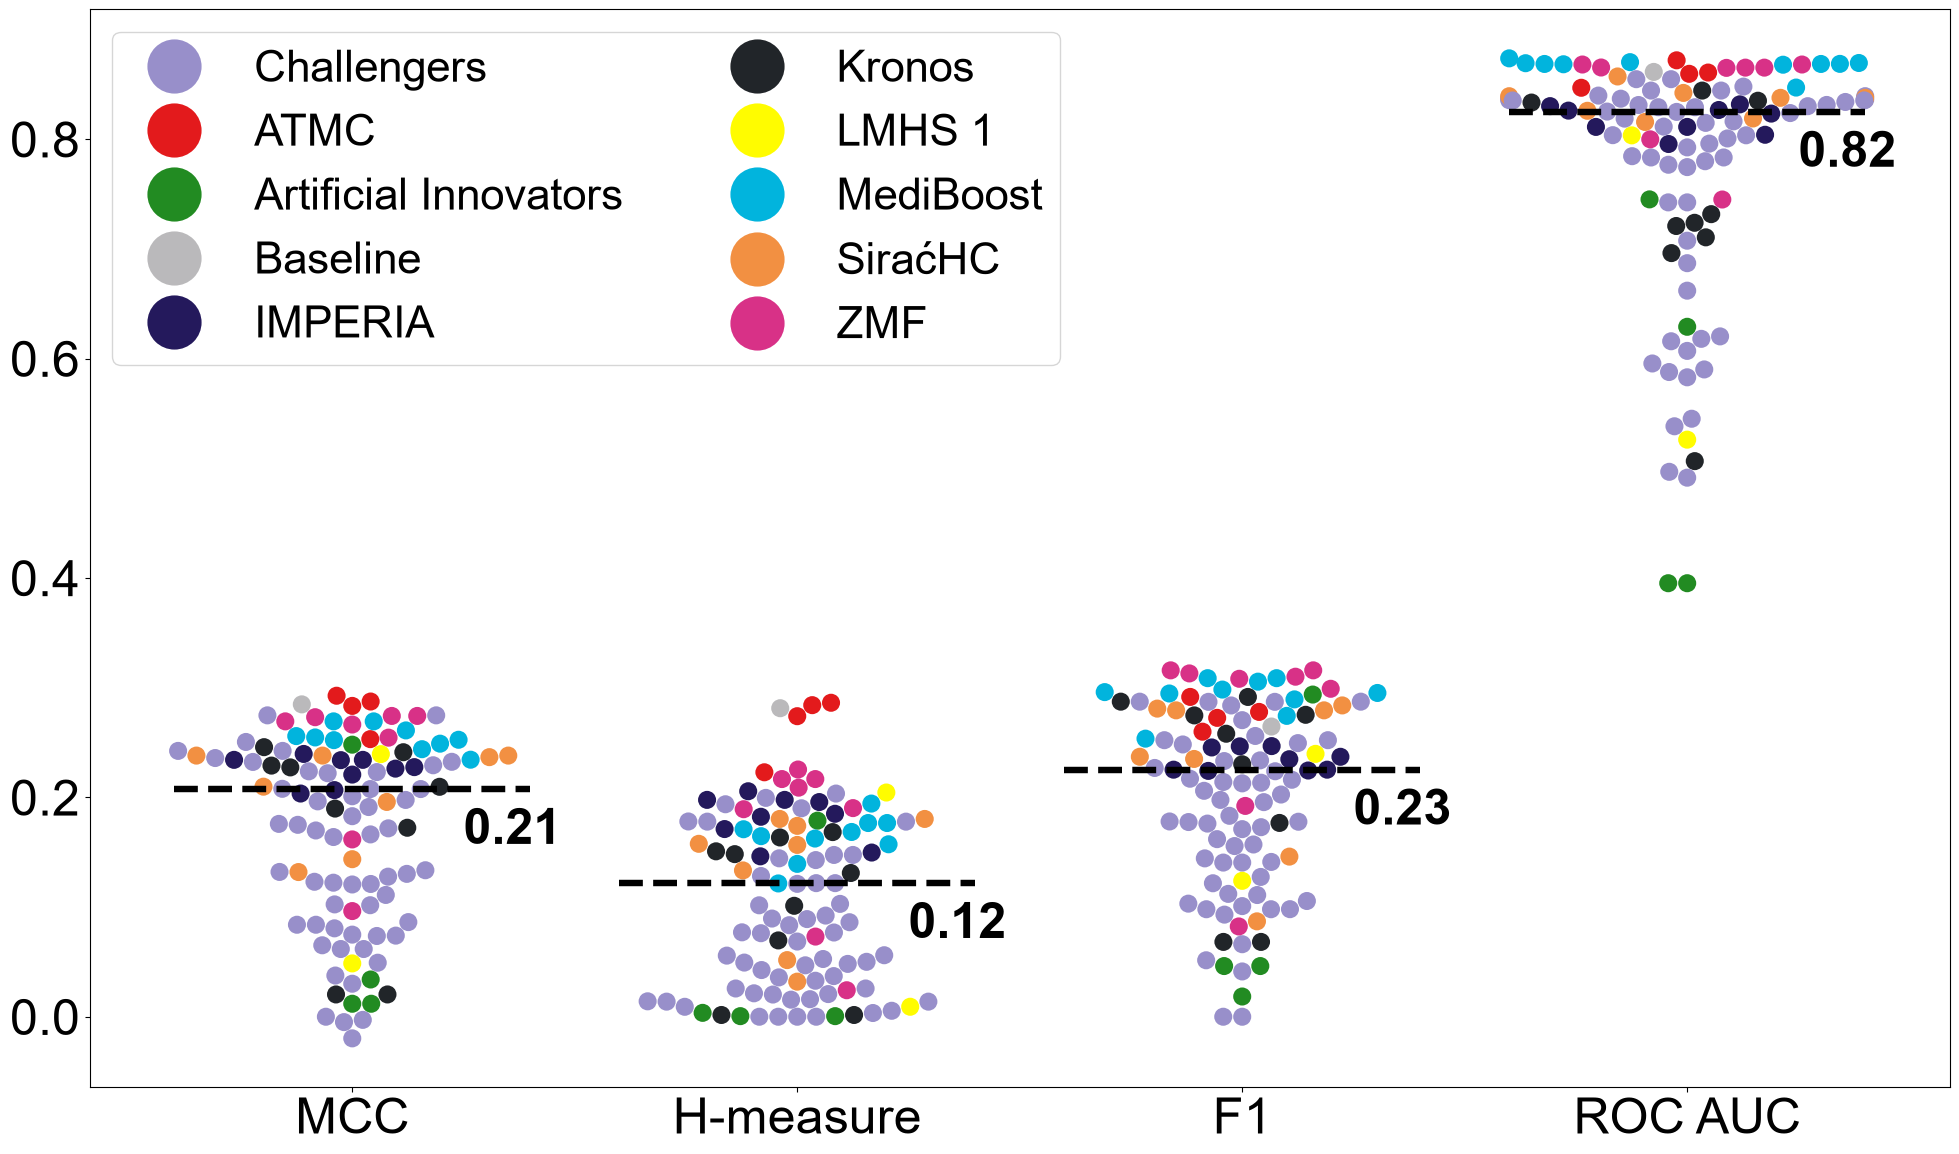

In [12]:
plt.figure(figsize=(24,14))
sns.swarmplot(x="Metric", y="Value", data=df_m, palette=palette, hue ='Teams', zorder=0, s=13)
# add median value as a line to the plot 
medians = df_swarmplot.median()
vertical_offset = df_swarmplot.median() * 0.05 # offset from median for display
for xtick in range(len(df_swarmplot.columns)-1):
    if xtick == 3:
        plt.text(xtick+0.36, medians[xtick]-0.05, round(medians[xtick],2), 
            horizontalalignment='center', size=FONTSIZE, 
            color='black', weight='semibold')
    else:
        plt.text(xtick+0.36, medians[xtick]-0.05, round(medians[xtick],2), 
            horizontalalignment='center', size=FONTSIZE, 
            color='black', weight='semibold')
    plt.plot((xtick-0.4,xtick+0.4 ), (medians[xtick], medians[xtick]), 
            color='black', linestyle='--', linewidth=4.64, zorder=1)
# hite x axis name na y axis name
plt.ylabel('Value', fontsize=FONTSIZE+2, visible=False, fontname=FONTNAME)
plt.xlabel('Metrics', fontsize=FONTSIZE+2, visible=False, fontname=FONTNAME)
plt.xticks(fontsize=FONTSIZE, fontname=FONTNAME)
plt.yticks(fontsize=FONTSIZE, fontname=FONTNAME)
plt.legend(loc='upper left', ncol=2, fontsize=FONTSIZE-4, markerscale=MARKERSCALE-1)
# plt.title('Synthetic data - Phase 1', fontsize=FONTSIZE+4)
title = 'phase_1_swarmplot_metrics'
os.makedirs('images', exist_ok=True)
plt.savefig(f'images/{title}.pdf', bbox_inches='tight', format="pdf")
# Show the plot
plt.show()



In [13]:
# testing function deletes all metrics_public.csv and metrics_private.csv
# files in all Tim_* and Baseline folders
def clean():
    tim_dirs = ['Tim_{:02d}'.format(i) for i in range(1, 29)] + ['Baseline']
    for i in tim_dirs:
        submissions_folder_path="./EDIH_AI4Health_Challenge/" + i 
        os.makedirs(submissions_folder_path, exist_ok=True)
        df = pd.DataFrame(columns=["Team", "Date", "Order", 
                    "H_measure", "MCC", "F1", "ROC_AUC", "Accuracy"
                ])
        df.to_csv(submissions_folder_path + '/metrics_public.csv')
        df.to_csv(submissions_folder_path + '/metrics_private.csv')
# clean()

In [14]:
from evaluate_phase1 import Eval

e = Eval()
e.read_data()

\metrics_public.csv
Baseline_1_27022024.csv 1
task_phase1\EDIH_AI4Health_Challenge\Baseline\Baseline_1_27022024.csv
************************************************** True **************************************************
2026-07-21 1
************************************************** True **************************************************
2026-07-21 1
DF PRIVATE SUCCESSFULLY UPDATED
\metrics_public.csv


c:\Experiments\chpkg\challenge_rehospitalization_2024\evaluate_phase1.py:195: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(new_row, ignore_index=True)
c:\Experiments\chpkg\challenge_rehospitalization_2024\evaluate_phase1.py:195: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(new_row, ignore_index=True)


accelerate healthcare_0_09.03.2024.csv 0
task_phase1\EDIH_AI4Health_Challenge\Tim_01\Submission\accelerate healthcare_0_09.03.2024.csv
No 'Label' column in the file
************************************************** False **************************************************
yhat and testy have different lengths!!!!!!!
2026-07-21 0
yhat and testy have different lengths!!!!!!!
2026-07-21 0
DF PRIVATE SUCCESSFULLY UPDATED


c:\Experiments\chpkg\challenge_rehospitalization_2024\evaluate_phase1.py:195: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(new_row, ignore_index=True)
c:\Experiments\chpkg\challenge_rehospitalization_2024\evaluate_phase1.py:195: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(new_row, ignore_index=True)


accelerate healthcare_1_10.03.2024.cs.csv 1
task_phase1\EDIH_AI4Health_Challenge\Tim_01\Submission\accelerate healthcare_1_10.03.2024.cs.csv
************************************************** True **************************************************
yhat and testy have different lengths!!!!!!!
2026-07-21 1
yhat and testy have different lengths!!!!!!!
2026-07-21 1
DF PRIVATE SUCCESSFULLY UPDATED


...

c:\Experiments\chpkg\challenge_rehospitalization_2024\evaluate_phase1.py:195: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(new_row, ignore_index=True)
c:\Experiments\chpkg\challenge_rehospitalization_2024\evaluate_phase1.py:195: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(new_row, ignore_index=True)


Tim-C_1_05032024.csv 1
task_phase1\EDIH_AI4Health_Challenge\Tim_28\Submission\Tim-C_1_05032024.csv
************************************************** True **************************************************
2026-07-21 1
************************************************** True **************************************************
2026-07-21 1
DF PRIVATE SUCCESSFULLY UPDATED


c:\Experiments\chpkg\challenge_rehospitalization_2024\evaluate_phase1.py:195: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(new_row, ignore_index=True)
c:\Experiments\chpkg\challenge_rehospitalization_2024\evaluate_phase1.py:195: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(new_row, ignore_index=True)


Tim-C_4_08032024.csv 4
task_phase1\EDIH_AI4Health_Challenge\Tim_28\Submission\Tim-C_4_08032024.csv
************************************************** True **************************************************
2026-07-21 4
************************************************** True **************************************************
2026-07-21 4
DF PRIVATE SUCCESSFULLY UPDATED
\metrics_public.csv


c:\Experiments\chpkg\challenge_rehospitalization_2024\evaluate_phase1.py:195: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(new_row, ignore_index=True)
c:\Experiments\chpkg\challenge_rehospitalization_2024\evaluate_phase1.py:195: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(new_row, ignore_index=True)


## Synthetic data ROC AUC and PR plots

Final metrics private calculation ROC AUC plots

In [15]:
team_dirs = []
for team in cmap.keys():
    if team in ['Baseline', 'irb-red', 'irb-blue', 'irb-gray', 'Challengers']:
        continue
    elif team in cmap.keys():
        team_dirs.append(bw_teams[team])
        
        # print(team_dir)
final_submissions = {}
for team in team_dirs:
    met = pd.read_csv(f'task_phase1/EDIH_AI4Health_Challenge/{team}/metrics_private2.csv')
    fname = met['fname'].values[-1]
    print(fname, team)
    final_submissions[teams[team]] = pd.read_csv(f'task_phase1/EDIH_AI4Health_Challenge/{team}/Submission/{fname}')
    
    # df_pred = pd.read_csv(f'task_phase1/EDIH_AI4Health_Challenge/{team_dir}/Submission/predictions.csv')
    # e.calc_public_metrics(df, f'task_phase1/EDIH_AI4Health_Challenge/{team}/predictions.csv')
    # e.calc_private_metrics(df, f'task_phase1/EDIH_AI4Health_Challenge/{team}/predictions.csv')
    # e.clean_self()

MediBoost_9_20240309.csv Tim_14
Kronos_9_09-03-2024.csv Tim_10
SiraćHC_9_10032024.txt Tim_21
ZMF_8_10.03.2024.csv Tim_25
ATMC_4_10_3_2024.csv Tim_03
Tim08_1_3.3.2024.csv Tim_08
LMHS1_2_10.3..csv Tim_12
ArtificialInnovators_4_10.3.2024.csv Tim_02


In [16]:
final_submissions

{'MediBoost':       Label  Probability_0  Probability_1
 0         0       0.995699       0.004301
 1         0       0.954053       0.045947
 2         0       0.998532       0.001468
 3         0       0.995440       0.004560
 4         0       0.987578       0.012422
 ...     ...            ...            ...
 7331      0       0.979418       0.020582
 7332      0       0.998642       0.001358
 7333      0       0.969390       0.030610
 7334      0       0.997824       0.002176
 7335      0       0.930833       0.069167
 
 [7336 rows x 3 columns],
 'Kronos':       Label  Probability_0  Probability_1
 0         0       0.527677       0.472323
 1         0       0.594593       0.405407
 2         0       0.561053       0.438947
 3         0       0.563095       0.436905
 4         0       0.506234       0.493766
 ...     ...            ...            ...
 7331      0       0.513280       0.486720
 7332      0       0.526922       0.473078
 7333      0       0.578102       0.421898
 73

In [17]:
e.testy

0       0
1       1
2       0
3       0
4       0
       ..
7331    0
7332    0
7333    0
7334    0
7335    0
Name: Label, Length: 7336, dtype: int64

Error with IMPERIA


C:\Users\keber\AppData\Local\Temp\ipykernel_39864\1390280291.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', label='Random (0.5)', linewidth=4, color='black')


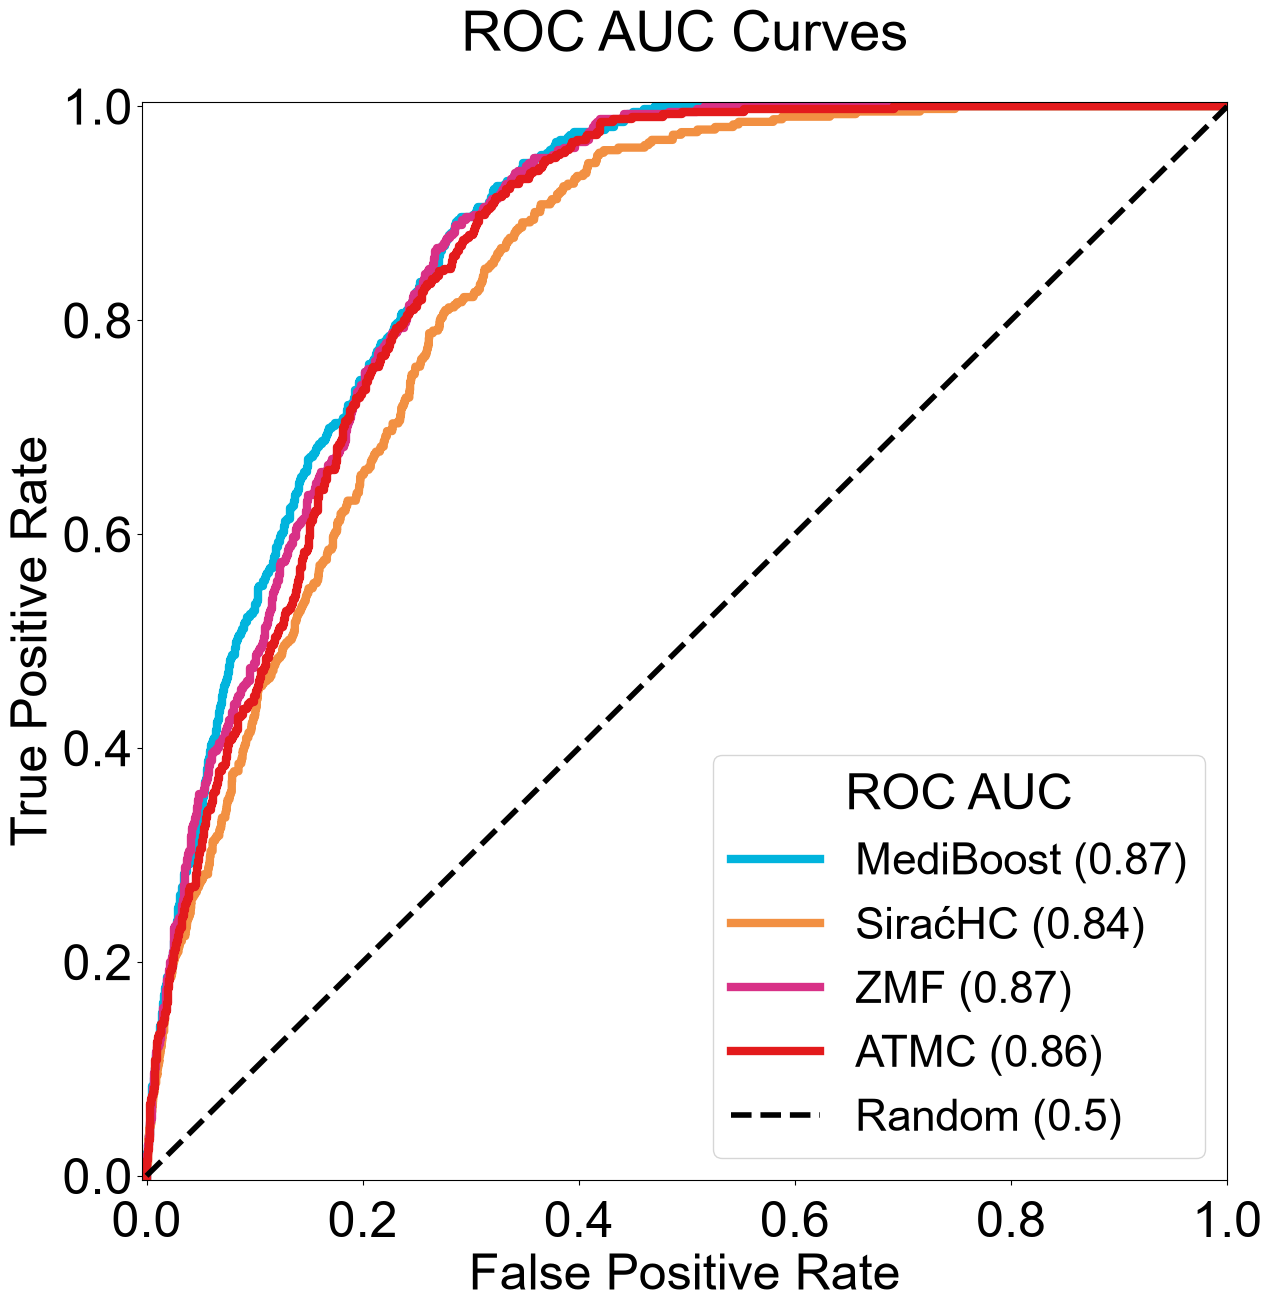

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 14))

for team, submission in final_submissions.items():
    try:
        fpr, tpr, _ = roc_curve(e.testy, submission['Probability_1'].values)
        roc_auc = roc_auc_score(e.testy, submission['Probability_1'].values)
        if roc_auc > 0.83:
            plt.plot(fpr, tpr, label=f'{team} ({roc_auc:.2f})', color=cmap[team], linewidth=6)
    except:
        print(f"Error with {team}")
plt.plot([0, 1], [0, 1], 'k--', label='Random (0.5)', linewidth=4, color='black')
plt.xlabel('False Positive Rate', fontsize = FONTSIZE, fontname=FONTNAME)
plt.ylabel('True Positive Rate', fontsize = FONTSIZE, fontname=FONTNAME)
plt.title('ROC AUC Curves', fontsize = FONTSIZE+4, y=1.04, fontname=FONTNAME)
# add space between title and plot
# plt.subplots_adjust(top=1.9)
# plt.axvline(x=0.18, color=cmap['irb-blue'], linestyle='--', linewidth=4)
# plt.axhline(y=0.71, color=cmap['Challengers'], linestyle='--', linewidth=4)
# plt.annotate('FPR = 0.18', xy=(0.18, 0.71), xytext=(0.28, 0.77),
#             arrowprops=dict(facecolor='black', arrowstyle='->', lw = 4, color=cmap['irb-blue']), 
#             fontsize=FONTSIZE-4, color=cmap['irb-blue'])
# plt.annotate('TPR = 0.71', xy=(0.18, 0.71), xytext=(0.22, 0.65),
#             arrowprops=dict(facecolor='black', arrowstyle='->', lw = 4, color=cmap['Challengers']), 
#             fontsize=FONTSIZE-4, color=cmap['Challengers'])
plt.legend(loc='lower right', fontsize=FONTSIZE-4, markerscale=MARKERSCALE+10, 
        title='ROC AUC', title_fontsize = FONTSIZE)
plt.xticks(fontsize=FONTSIZE, y=-0.01)
plt.yticks(fontsize=FONTSIZE, y=-0.01)
plt.xlim(-0.004, 1)
plt.ylim(-0.004, 1.004)
# plt.grid(True)
title = 'phase_1_roc_auc_curves'
os.makedirs('images', exist_ok=True)
plt.savefig(f'images/{title}.pdf', bbox_inches='tight', format="pdf")
plt.show()

Error with IMPERIA: length mismatch
Error with IMPERIA


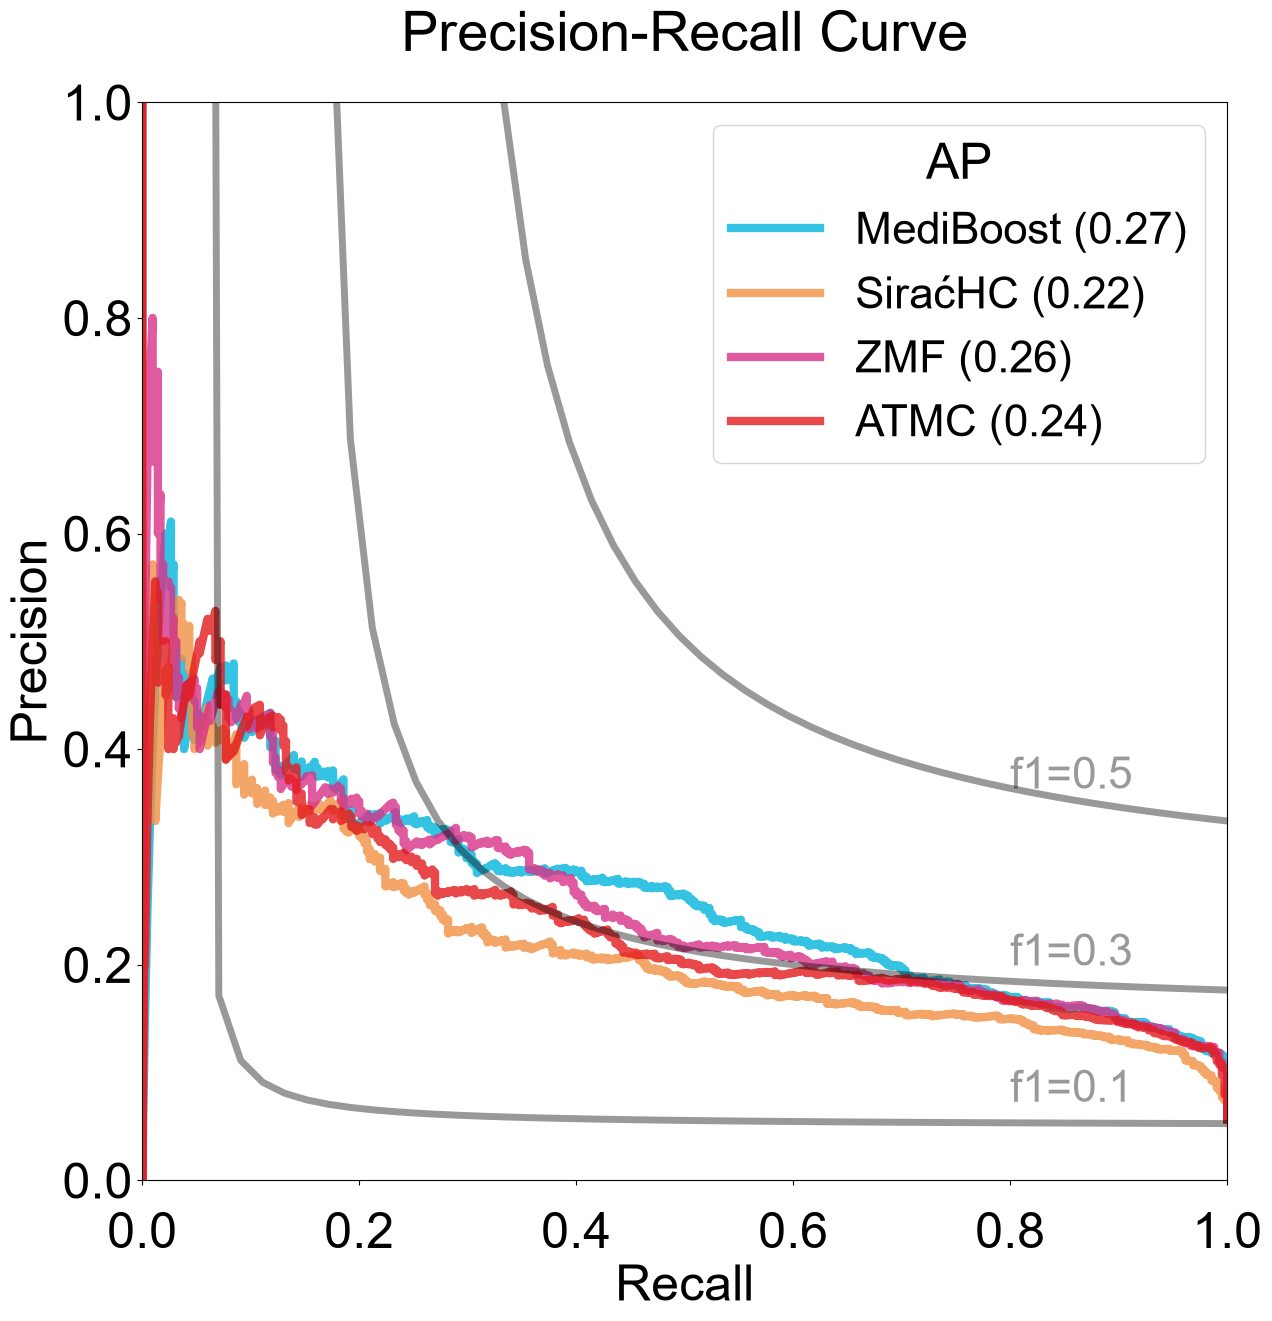

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(14, 14))
mAP = []
for team, submission in final_submissions.items():
    if len(e.testy) != len(submission['Probability_1'].values):
        print(f"Error with {team}: length mismatch")
        continue
    average_precision = average_precision_score(e.testy, submission['Probability_1'].values)

    mAP.append(average_precision.mean())

mAPmean = np.array(mAP).mean()
for team, submission in final_submissions.items():
    try:
        precision, recall, _ = precision_recall_curve(
            e.testy, submission['Probability_1'].values)
        
        average_precision = average_precision_score(
            e.testy, submission['Probability_1'].values)
        
        if average_precision.mean()>mAPmean:
            mAP = average_precision.mean()
            plt.plot(recall, precision, color=cmap[team], 
                    label=f'{team} ({mAP:.2f})', linewidth=6, alpha=0.8,)
            
    except:
        print(f"Error with {team}")
f_scores = np.linspace(0.1, 0.5, num=3)
lines, labels = [], []
for f_score in f_scores:
    x = np.linspace(0.01, 1)
    y = f_score * x / (2 * x - f_score)
    (l,) = plt.plot(x[y >= 0], y[y >= 0], color="black", alpha=0.4, linewidth=5)
    plt.annotate("f1={0:0.1f}".format(f_score), xy=(0.8, y[45] + 0.02), 
        fontsize=FONTSIZE-4, color='black', alpha=0.4, fontname=FONTNAME)

    # plt.axhline(y=0.29, color=cmap['Challengers'], linestyle='--', linewidth=4)
    # plt.annotate('0.3', xy=(0.4, 0.29), xytext=(0.5, 0.295), 
    #     arrowprops=dict(facecolor='black', arrowstyle='->', color=cmap['Challengers'],lw=4),
    #     fontsize=FONTSIZE-4, color=cmap['Challengers'], fontname=FONTNAME) 

    # plt.axvline(x=0.4, color=cmap['irb-blue'], linestyle='--', linewidth=4)
    # plt.annotate('0.4', xy=(0.405, 0.305), xytext=(0.405, 0.355),
    #     arrowprops=dict(facecolor='black', arrowstyle='->', lw = 4, color=cmap['irb-blue']),
    #     fontsize=FONTSIZE-4, color=cmap['irb-blue'], fontname=FONTNAME)

plt.xlabel('Recall', fontsize=FONTSIZE, fontname=FONTNAME)
plt.ylabel('Precision', fontsize=FONTSIZE, fontname=FONTNAME)
plt.title('Precision-Recall Curve', fontsize = FONTSIZE+4, y=1.04, fontname=FONTNAME)
plt.legend(loc='upper right', fontsize=FONTSIZE-4, title='AP', title_fontsize=FONTSIZE)
plt.xticks( fontsize=FONTSIZE, y=-0.02, fontname=FONTNAME)
plt.yticks(fontsize=FONTSIZE, fontname=FONTNAME)
plt.xlim(0, 1)
plt.ylim(0, 1)
# plt.grid(True)

title = 'phase_1_precision_recall_curve'
os.makedirs('images', exist_ok=True)
plt.savefig(f'images/{title}.pdf', bbox_inches='tight', format="pdf")
plt.show()